Task 0：先用「長尺度 × 短尺度」看出雙尺度（envelope + 細節） 

In [180]:
# 引入模組
import numpy as np
import matplotlib.pyplot as plt

In [181]:
# 設定空間範圍
x = np.linspace(-30, 30, 2000)

# 參數設定
k = 0.3          # 長尺度（小 k → 慢變）
a = 2            # 晶格常數（小 a → 快變）

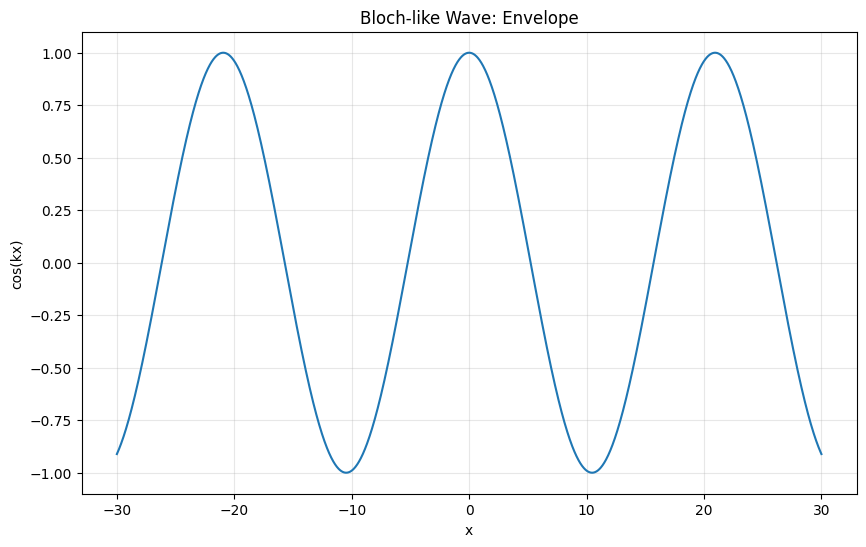

In [182]:
# 長尺度（平面波）
envelope = np.cos(k * x)

plt.figure(figsize=(10,6))
plt.plot(x, envelope)
plt.title("Bloch-like Wave: Envelope")
plt.xlabel("x")
plt.ylabel("cos(kx)")
plt.grid(alpha=0.3)
plt.show()

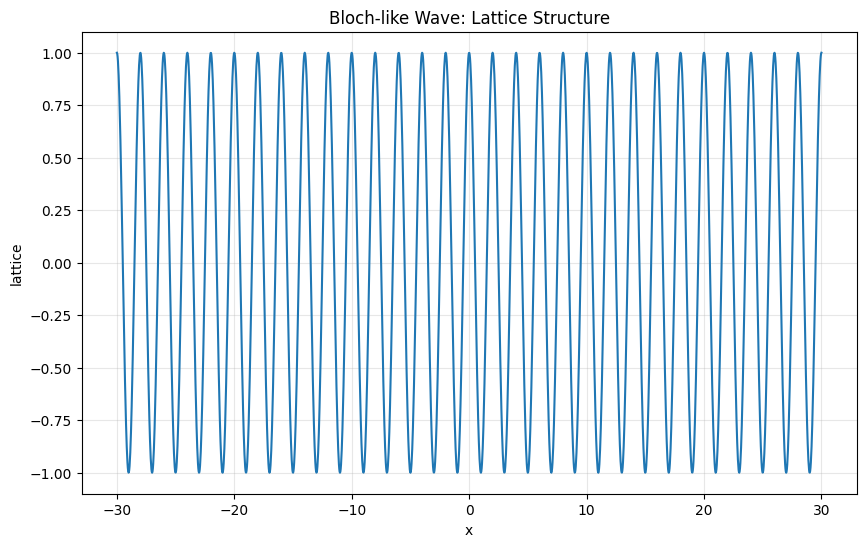

In [183]:
# 短尺度（週期函數）
lattice = np.cos(2 * np.pi * x / a)

plt.figure(figsize=(10,6))
plt.plot(x, lattice)
plt.title("Bloch-like Wave: Lattice Structure")
plt.xlabel("x")
plt.ylabel("lattice")
plt.grid(alpha=0.3)
plt.show()

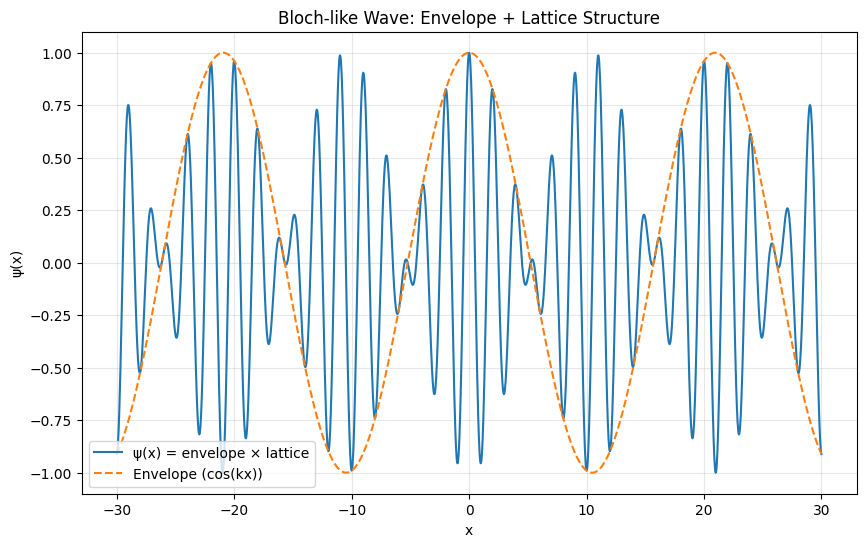

In [184]:
# 總波函數
psi = envelope * lattice

# 畫畫畫畫畫總波函數
plt.figure(figsize=(10,6))
plt.plot(x, psi, label='ψ(x) = envelope × lattice')
plt.plot(x, envelope, '--', label='Envelope (cos(kx))')
plt.title("Bloch-like Wave: Envelope + Lattice Structure")
plt.xlabel("x")
plt.ylabel("ψ(x)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Task 1 組出 Bloch 波，並驗證平移只差一個相位

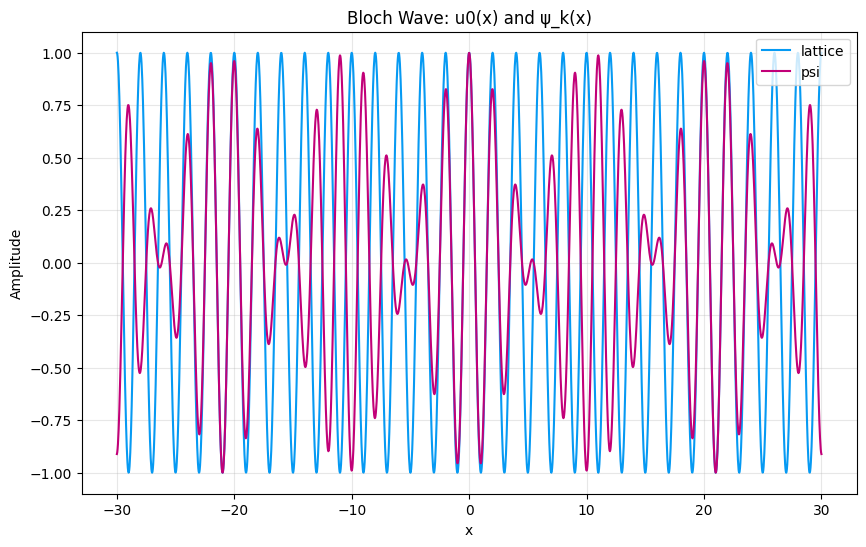

In [185]:
# (a)圖像拆解
plt.figure(figsize=(10,6))
# 畫 u0(x)
plt.plot(x, lattice, label='lattice', color='#069AF3')
# 畫 Re(ψ)
plt.plot(x, psi, label='psi', color='#C20078')
plt.title("Bloch Wave: u0(x) and ψ_k(x)")
plt.xlabel("x")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [186]:
# (b) 平移驗證
#＃ 定義函數
def u0(x):
    return np.cos(2*np.pi*x/a)

def psi_k(x):
    return u0(x) * np.exp(1j * k * x)

lattice = u0(x)
psi = psi_k(x)

In [187]:
# 平移後
psi_shift_real = psi_k(x + a)

In [188]:
# 理論預測
phase_factor = np.exp(1j * k * a)
psi_shift_expected = phase_factor * psi

In [189]:
# 比較誤差
error = np.max(np.abs(psi_shift - psi_shift_expected))

print("=== 平移驗證 ===")
print(f"e^(i k a) = {phase_factor}")
print(f"最大誤差 = {error:.2e}")

=== 平移驗證 ===
e^(i k a) = (0.8253356149096783+0.5646424733950354j)
最大誤差 = 1.99e+00


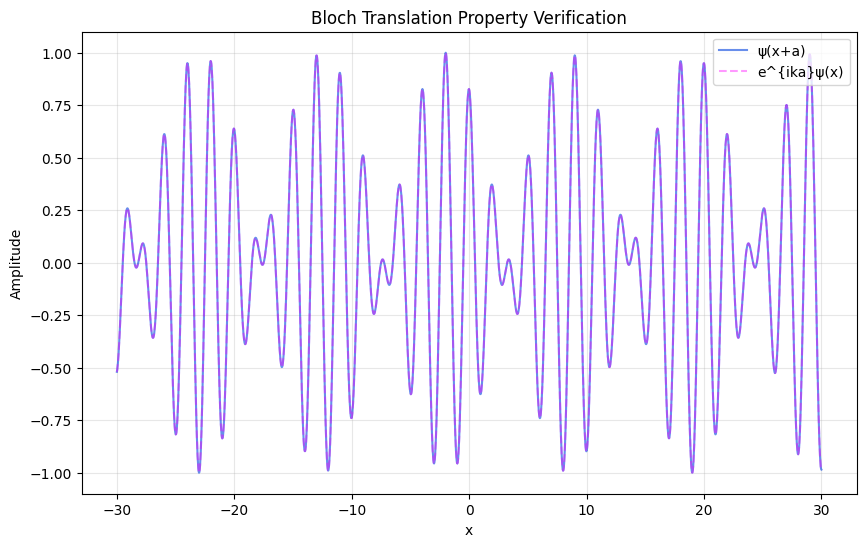

In [190]:
# 畫畫畫畫畫比較圖
plt.figure(figsize=(10,6))
plt.plot(x, psi_shift_real, label='ψ(x+a)', color='#0343DF', alpha=0.6)
plt.plot(x, psi_shift_expected, label='e^{ika}ψ(x)',linestyle='--', color='#FF00FF', alpha=0.4)
plt.title("Bloch Translation Property Verification")
plt.xlabel("x")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Task 2 掃描 𝒌：觀察相鄰原子間的相位變化

In [191]:
# k 值掃描
k_values = [0, np.pi/(4*a), np.pi/(2*a), 3*np.pi/(4*a), np.pi/a]

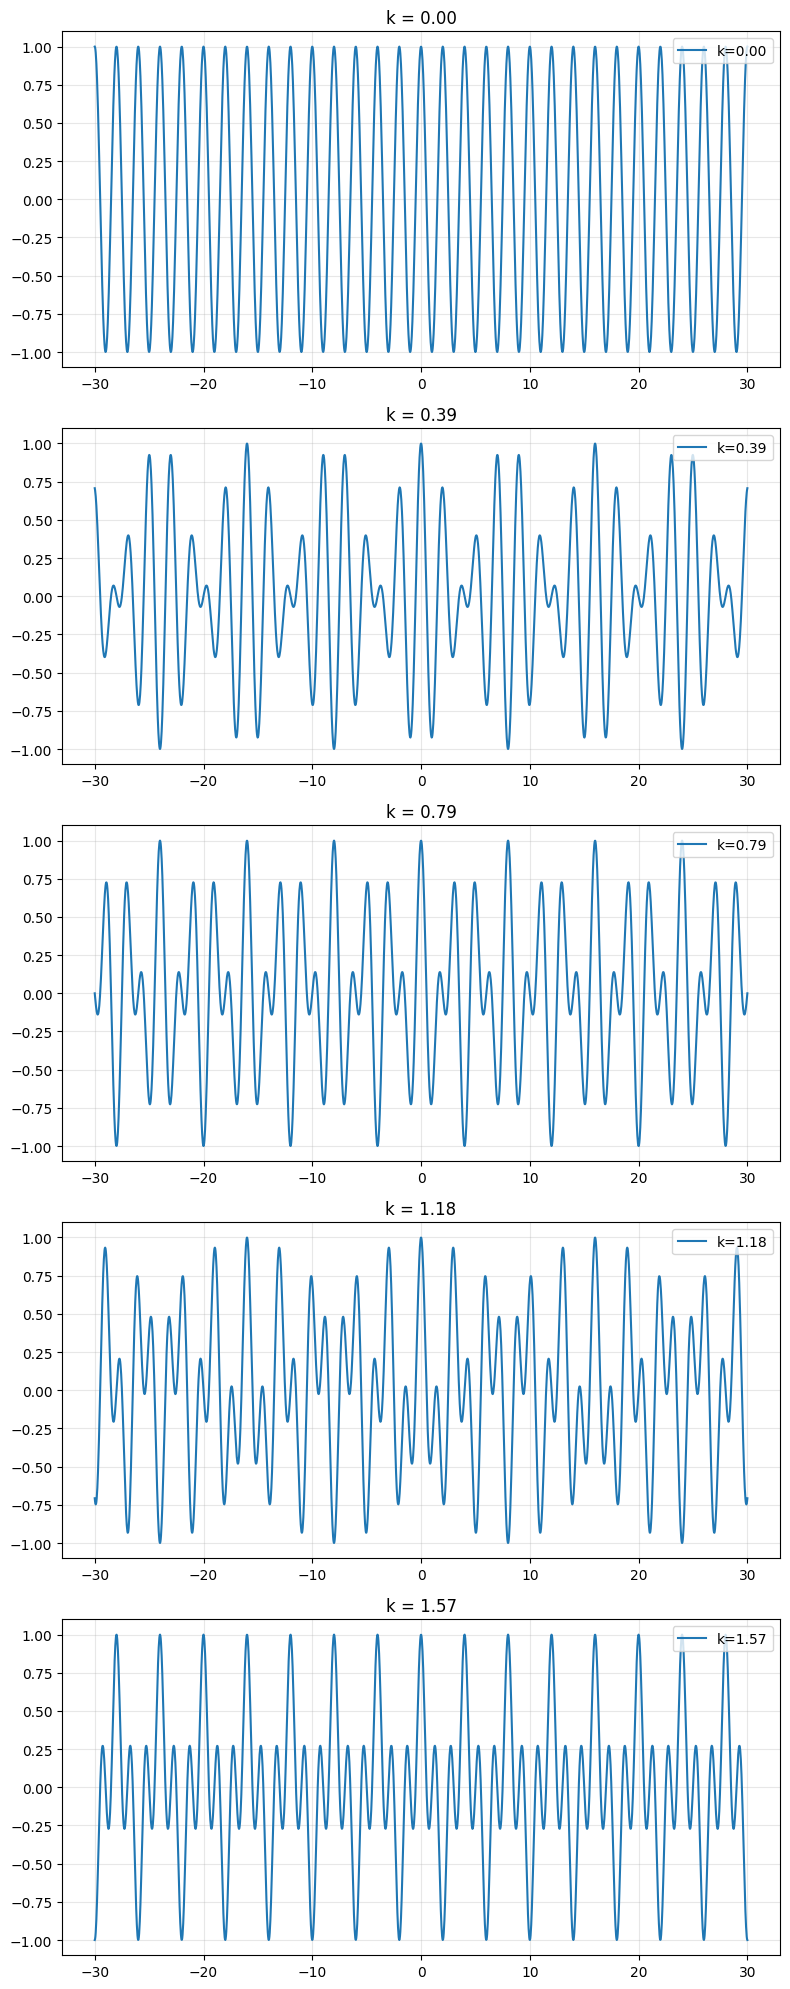

In [192]:
# 畫畫畫畫畫圖
fig, axes = plt.subplots(len(k_values), 1, figsize=(8, 20))

for i, k in enumerate(k_values):
    
    psi = u0(x) * np.exp(1j * k * x)
    axes[i].plot(x, np.real(psi), label=f"k={k:.2f}")
    axes[i].set_title(f"k = {k:.2f}")
    axes[i].legend(loc='upper right')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

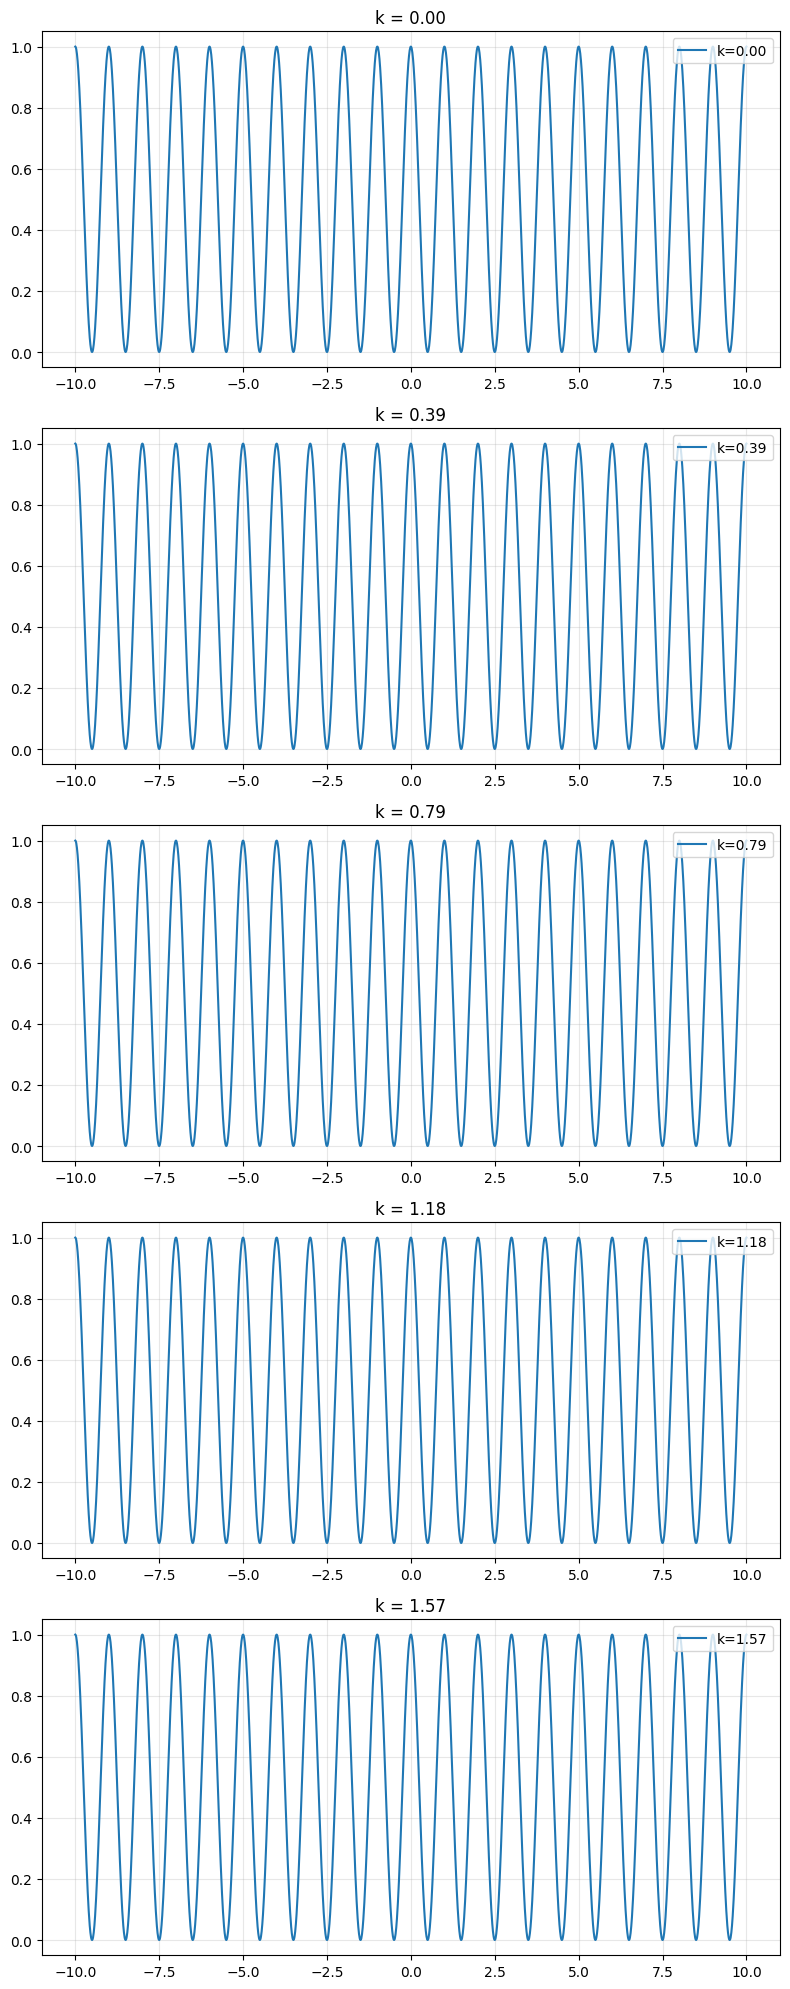

In [194]:
# 機率密度
x = np.linspace(-10, 10, 2000)
fig, axes = plt.subplots(len(k_values), 1, figsize=(8, 20))

for i, k in enumerate(k_values):
    
    psi = u0(x) * np.exp(1j * k * x)
    axes[i].plot(x, np.abs(psi)**2, label=f"k={k:.2f}")
    axes[i].set_title(f"k = {k:.2f}")
    axes[i].legend(loc='upper right')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()